# Problem Set 6: Neural Networks


<span style="color:red">Warning!</span> Some of the problems in this problem set require heavy computation - you are encouraged to start early so that you don't get stuck at the last minute.

<span style="color:red">Note:</span> Lab 7 and (specially) lab 8 are your friends -- many of the examples will help you answer questions in this problem set. 

## Truck v/s Cars: Neural Networks and Image Classification

Your goal for this problem set is to train neural network models for image classification. Specifically, your task is to train models that correctly predict where the vehicle in a given image is a truck, or a car / automobile.

It might be useful to start by implementing this entire problem set on a relatively small subset of all of the images first, before using the full dataset.

From a coding perspective, it will be easiest to complete all the problems using pytorch; however, if you prefer to use keras / tensorflow or any other deeplearning API, feel free to do so. 

## Part I. Convolutions

### Question 1: Load Data +  Exploratory Analysis

For this problem, we'll load the [CIFAR 10](https://en.wikipedia.org/wiki/CIFAR-10) dataset
. This dataset has been widely used in ML and computer vision research -- you can read more about the state of the art model performance (and how this has improved over time) [here](https://en.wikipedia.org/wiki/CIFAR-10).

The CIFAR 10 dataset originally has 10 classes -- we've provided helper code below to load the data. We will use this dataset for a supervised binary classification problem.

Your tasks:
- Create a subset of the CIFAR 10 data, keeping only the car (automobile) and truck classes.  
- Select 9 random images from your training set. Plot these images in a 3 X 3 grid, along with the corresponding category / label

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import Subset

def load_cifar10_filtered(data_path):
    """
    Load automobile and truck instances in CIFAR10 train and test datasets.
    """

    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    cifar10_train = datasets.CIFAR10(
        data_path,
        train=True,
        download=True,
        transform=transform
    )

    cifar10_test = datasets.CIFAR10(
        data_path,
        train=False,
        download=True,
        transform=transform
    )

    return cifar10_train, cifar10_test

In [25]:
## Load CIFAR data
datapath = '../data-unversioned/p1ch6/'
cifar10_train, cifar10_test = load_cifar10(datapath)
print(cifar10_train.classes)
print(cifar10_train[0][0].shape)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
torch.Size([3, 32, 32])


In [ ]:
### YOUR CODE HERE

In [26]:
wanted_classes = {"automobile", "truck"}

class_ids_train = [cifar10_train.class_to_idx[c] for c in wanted_classes]
indices = [i for i, y in enumerate(cifar10_train.targets) if y in class_ids_train]
cifar10_train = Subset(cifar10_train, indices)

class_ids_test = [cifar10_test.class_to_idx[c] for c in wanted_classes]
indices = [i for i, y in enumerate(cifar10_test.targets) if y in class_ids_test]
cifar10_test = Subset(cifar10_test, indices)

In [ ]:
### YOUR CODE HERE

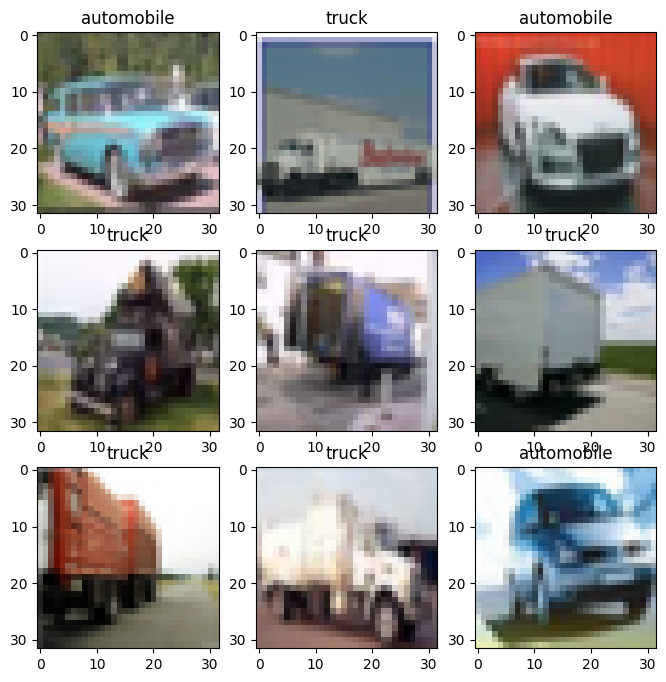

In [34]:
import matplotlib.pyplot as plt

img_idxs = [np.random.randint(len(cifar10_train)) for _ in range(9)]
fig, ax = plt.subplots(figsize = (8, 8), nrows = 3, ncols = 3)
for i in range(9):
    img, label = cifar10_train[img_idxs[i]]
    ax[i//3, i%3].imshow(img.permute(1,2,0))
    ax[i//3, i%3].set_title(cifar10_train.dataset.classes[label])
plt.show()

In [ ]:
# YOUR CODE HERE

In [35]:
label_map = {
    cifar10_train.dataset.class_to_idx["automobile"]: 0,
    cifar10_train.dataset.class_to_idx["truck"]: 1,
}

for subset in (cifar10_train, cifar10_test):
    targets = subset.dataset.targets
    for i in subset.indices:
        targets[i] = label_map[targets[i]]

### Question 2: A convolutional layer with a single filter

Let's build some intuition for what convolutions actually do. First, complete the following steps. Then, answer the questions below. 

1. initizialize a convolutional layer (using nn.Conv2d):
    - in_channels: 3
    - out_channels: 1
    - kernel_size: 3
    - padding: 1

2. Assign the following weights to each incoming channel of the convolutional layer:

\begin{align*}
\begin{bmatrix}
    -1.0 & -1.0 & -1.0\\
    0.0 & 0.0 & 0.0 \\
    1.0 & 1.0 & 1.0\\
\end{bmatrix}
\end{align*}

3. Pick an image from the training dataset at random and passe it through this convolutional layer

4. Plot the raw image, and the resulting output

Then, answer the following questions:

What do you notice about the output image? After applying the convolutional filter, what kind of features are more prominent / enhanced? Why is this the case (or in other words, what does step 2 help us achieve?)?
       
Hint 1: Review the documentation for [nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)\
Hint 2: Use conv.weight[:] to set the weights, where "conv" is the name of your convolutional layer.

In [71]:
# YOUR CODE HERE

import torch

conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
 
with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, -1.0, -1.0],
                                    [0.0, 0.0, 0.0],
                                    [1.0, 1.0, 1.0]])
    conv.bias.zero_()

In [101]:
test_img, _ = cifar10_train[np.random.randint(len(cifar10_train))]
output = conv(test_img.unsqueeze(0))[0, 0].detach()

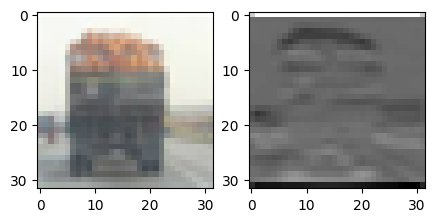

In [102]:
fig, ax = plt.subplots(figsize = (5, 5), ncols = 2)
ax[0].imshow(test_img.permute(1, 2, 0), cmap = 'grey')
ax[1].imshow(output, cmap = 'grey')
plt.show()

### Question 3: A convolutional layer with two filters

Augment the convolutional layer from question 2 with a second convolutional filter that is the transpose of the original filter.

\begin{align*}
\begin{bmatrix}
    -1.0 & 0.0 & 1.0\\
    -1.0 & 0.0 & 1.0 \\
    -1.0 & 0.0 & 1.0\\
\end{bmatrix}
\end{align*}

As with the original filter, this second filter should also be used for all incoming channels. Since you now have two filters, there should be two outgoing channels instead of 1. Once again, pick an image at random and show the original image, the output of the first filter and the output of the second filter side by side. 


In [145]:
# YOUR CODE HERE

import torch

conv = nn.Conv2d(3, 2, kernel_size=3, padding=1)
 
with torch.no_grad():
    conv.weight[:] = torch.tensor(
        [
            [[
                [-1.0, -1.0, -1.0],
                [0.0, 0.0, 0.0],
                [1.0, 1.0, 1.0]
            ]],
            [[
                [-1.0, 0.0, 1.0],
                [-1.0, 0.0, 1.0],
                [-1.0, 0.0, 1.0]
            ]]
        ]
    )
    conv.bias.zero_()

In [147]:
test_img, _ = cifar10_train[np.random.randint(len(cifar10_train))]
output_filter_h = conv(test_img.unsqueeze(0))[0, 0].detach()
output_filter_v = conv(test_img.unsqueeze(0))[0, 1].detach()

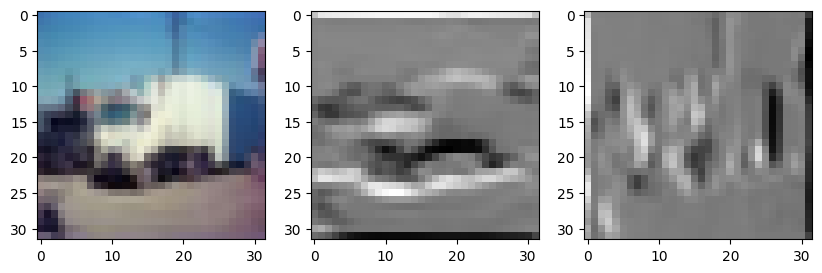

In [148]:
fig, ax = plt.subplots(figsize = (10, 10), ncols = 3)
ax[0].imshow(test_img.permute(1, 2, 0), cmap = 'grey')
ax[1].imshow(output_filter_h, cmap = 'grey')
ax[2].imshow(output_filter_v, cmap = 'grey')
plt.show()

## II. Neural Networks

### Question 4: Helper Functions

Complete the following functions:
- training: which invokes the training loop, similar to what we saw in Lab 9. 
- validate: given a trained model and data loader, generate performance metrics

Here is an example of how you will use these functions:

test_loader = ... (Define your data loader)

learning_rate = .. (define learning rate)\
neural_network = .. (initialize your neural network)\
optimizer = .. (set up your optimizer)\
loss_fn = .. (set up your loss function)

training( ....) 

validate(...)

In [163]:
def training(model, n_epochs, optimizer, fn_loss, data_loader):
    """
    Train a neural network model. (i.e this function invokes the training loop)
    ----------
    Parameters:
        
        model: torch model object
        n_epochs: number of epochs
        optimizer: torch.optim object
        fn_loss: torch loss function (torch.nn.modules.loss object)
        data_loader: torch data loader  
    ----------
    Returns:
        N/A
    """
    for epoch in range(1, n_epochs + 1):  
        train_loss = 0.0
        for imgs, labels in data_loader:  
            
            outputs = model(imgs)  
            
            loss = fn_loss(outputs, labels)
            
            optimizer.zero_grad() 
            loss.backward() 
            optimizer.step() 
            
            train_loss += loss.item()

        if epoch % 10 == 0:
            print(f'Epoch {epoch}. Train loss {train_loss / len(train_loader)}') 
    
def validate(model, data_loader):
    """
    Given a model and data loader, generate performance metrics. 
    -----------
    Parameters:
        model: (trained) neural network model
        data_loader: torch data loader
    """
    correct = 0
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    total = 0

    with torch.no_grad():  
        for imgs, labels in data_loader:
            outputs = model(imgs)
            _, predicted = torch.max(outputs, dim=1) 
            
            total += labels.shape[0]  
            correct += int((predicted == labels).sum())

            tp += int(((predicted == labels) & (labels == 1)).sum())
            fp += int(((predicted == 1) & (labels == 0)).sum())
            tn += int(((predicted == labels) & (labels == 0)).sum())
            fn += int(((predicted == 0) & (labels == 1)).sum())
                    
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2*precision*recall / (precision + recall)
    print(f"Accuracy: {correct / total:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1_score:.2f}")

### Question 5: Feedforward Neural Networks

Build a feedforward neural network with 2 hidden layers. You are expected to:

- Complete the FFN Class, based on the network architecture below (some scaffolding for this class is provided below, but feel free to write your own).
- Train / compile the network, following the guidelines below. 
- Report the accuracy, precision, recall and f1-score for the training and validation sets.
      

Network Architecture:
 - Input layer dimensions: 3 x 32 x 32 (C x W x H, where C = Number of Channels, W = width, H = Height)
 - Hidden layer 1: 256 nodes, relu activation

Compile:
- Optimizer: Adam
- Batch size: 32
  
Run the model for a minimum of 100 epochs. 

In [164]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [165]:
#### your code here

class FFN(nn.Module):
  def __init__(self):
    super(FFN, self).__init__()
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(32*32*3, 256)
    self.activation1 = nn.ReLU()
    self.linear2 = nn.Linear(256, 2)
      
  def forward(self, x):
    out = self.flatten(x)
    out = self.activation1(self.linear1(out))
    out = self.linear2(out)
    return out

In [166]:
train_loader = torch.utils.data.DataLoader(
    cifar10_train, 
    batch_size=32,
    shuffle=True
)

learning_rate = 0.01
ffn_model = FFN() 

optimizer = optim.Adam(ffn_model.parameters(), lr=learning_rate) 
loss_fn = nn.CrossEntropyLoss()  

training( 
    model = ffn_model,
    n_epochs = 500,
    optimizer = optimizer,
    
    fn_loss = loss_fn,
    data_loader = train_loader,
)

Epoch 10. Train loss 0.5847471369722019
Epoch 20. Train loss 0.5709366524181427
Epoch 30. Train loss 0.5619418032633992
Epoch 40. Train loss 0.5539633882121918
Epoch 50. Train loss 0.5512757760267288
Epoch 60. Train loss 0.54134931065404
Epoch 70. Train loss 0.5306211378627692
Epoch 80. Train loss 0.5340393464595746
Epoch 90. Train loss 0.5293917553112529
Epoch 100. Train loss 0.5325126914551463
Epoch 110. Train loss 0.5289916986474594
Epoch 120. Train loss 0.528121081499246
Epoch 130. Train loss 0.535887536911157
Epoch 140. Train loss 0.5202295267924714
Epoch 150. Train loss 0.5151483608891789
Epoch 160. Train loss 0.5207736355047257
Epoch 170. Train loss 0.5063853704700836
Epoch 180. Train loss 0.5118137897013094
Epoch 190. Train loss 0.5116726126724158
Epoch 200. Train loss 0.5163712928089471
Epoch 210. Train loss 0.5157563761590769
Epoch 220. Train loss 0.5050196257262184
Epoch 230. Train loss 0.507627486992187
Epoch 240. Train loss 0.5134907612404503
Epoch 250. Train loss 0.510336

In [167]:
train_loader = torch.utils.data.DataLoader(
    cifar10_train, 
    batch_size=32,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    cifar10_test,
    batch_size=32,
    shuffle=False
)

print("Training performance\n")
validate(ffn_model, train_loader)

print("\nValidation set performance\n")
validate(ffn_model, test_loader)

Training performance

Accuracy: 0.80
Precision: 0.78
Recall: 0.83
F1 Score: 0.80

Validation set performance

Accuracy: 0.68
Precision: 0.67
Recall: 0.72
F1 Score: 0.69


### Question 6: Convolutional Neural Networks

Build a convolutional neural network with two blocks, where each block is a convolutional layer followed by a max pooling layer. You are expected to:

- Complete the CNN Class, based on the network architecture below (some scaffolding for this class is provided below, but feel free to write your own).
- Train / compile the network, following the guidelines below. 
- Report the accuracy, precision, recall and f1-score for the training and validation sets.
      

Network Architecture:
 - Input layer dimensions:3 x 32 x 32 (C x W x H, where C = Number of Channels, W = width, H = Height)
 - Convolutional layer1:
     - Number of filters / kernels: 20
     - Dimensions: 3 x 3
     - Activation: ReLU
 - Convolutional layer 2:
     - Number of filters / kernels: 10
     - Dimensions: 3 x 3
     - Activation: ReLU

Compile:
- Optimizer: Adam
- Batch size: 32

Run the model for a minimum of 100 epochs. 

Note: Refer to lab 9 for an example of how to complete the CNN class

In [168]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
    self.activation1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(2)
    # self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
    # self.activation2 = nn.ReLU()
    # self.pool2 = nn.MaxPool2d(2)
    self.fc1 = nn.Linear(16 * 16 * 16, 2)

  def forward(self, x):
    out = self.pool1(self.activation1(self.conv1(x)))
    # out = self.pool2(self.activation2(self.conv2(out)))
    out = out.view(-1, 16 * 16 * 16) # <1>
    out = self.fc1(out)
    return out

In [169]:
train_loader = torch.utils.data.DataLoader(
    cifar10_train, 
    batch_size=32,
    shuffle = True
)

learning_rate = 0.01
cnn_model = CNN() 
optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate) 
loss_fn = nn.CrossEntropyLoss()  

training( 
    model = cnn_model,
    n_epochs = 50,
    optimizer = optimizer,
    
    fn_loss = loss_fn,
    data_loader = train_loader,
)

Epoch 10. Train loss 0.5775810453457574
Epoch 20. Train loss 0.47806712289968617
Epoch 30. Train loss 0.4319443957398113
Epoch 40. Train loss 0.42741798454770646
Epoch 50. Train loss 0.4321256179017381


In [170]:
train_loader = torch.utils.data.DataLoader(
    cifar10_train, 
    batch_size=32,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    cifar10_test, 
    batch_size=32,
    shuffle=False
)

print("Training performance\n")
validate(cnn_model, train_loader)

print("\nValidation set performance\n")
validate(cnn_model, test_loader)

Training performance

Accuracy: 0.81
Precision: 0.86
Recall: 0.73
F1 Score: 0.79

Validation set performance

Accuracy: 0.77
Precision: 0.81
Recall: 0.70
F1 Score: 0.75


### Question 7: your turn

Now, implement NewNet -- a convolutional network that you will build from scratch. The goal should be to exceed an F1 Score of 0.80. 
Note: We do not expect you to implement cross-validation or any formal hyperparameter optimization techniques (even though if you want to go the extra mile we encourage you to do so). Rather, the goal is to arrive at a model architecture that is acceptable via local experimentation (it shouldn't be too hard).  

Remember that you have a number of hyperparameters to work with, including
  - the number / dimension of hidden layers
  - choice of activation functions, 
  - type regularization, 
  - optimization techniques
  - batch normalization
  - and other relevant aspects(adding data augmentation etc.)

You may run the model for a maximum of 50 epochs. 
  
<!-- The notebooks from Labs 9 and 10 are a good starting point in terms of putting together a more complex architecture. 

<span style="color:red">Warning!</span> If you intend to attempt **Extra Credit 1 and 2** (below), ensure that you carefully name / store the trained model you build in this step. It's fine to keep trained model in memory, or to save the weights to disk.

   -->

**Outputs:**
 - Complete the NewNet class below with your model
 - Report the accuracy, recall, precision and f1-score on the training and validation sets. 
 - Briefly explain your model architecture / choices you made in tuning your CNN (No more than 3 - 4 sentences)
 - Compare your model performance (precision, recall, and overall classification accuracy) to the results obtained in questions 7 and 8.

In [171]:
class NewNet(nn.Module):
    def __init__(self, num_channels = 32):
        super().__init__()
        self.num_channels = num_channels
        self.conv1 = nn.Conv2d(3, num_channels, kernel_size = 3, padding = 1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features = num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels // 2, kernel_size = 3, padding = 1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features = num_channels // 2)
        self.fc1 = nn.Linear(8 * 8 * num_channels // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.num_channels // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [173]:
train_loader = torch.utils.data.DataLoader(cifar10_train, batch_size=32, shuffle = True)

learning_rate = 0.01
new_model = NewNet(num_channels = 32)
optimizer = optim.SGD(new_model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

training( 
    model = new_model,
    n_epochs = 50,
    optimizer = optimizer,
    
    fn_loss = loss_fn,
    data_loader = train_loader,
)

Epoch 10. Train loss 0.2787497794618622
Epoch 20. Train loss 0.18872663403114381
Epoch 30. Train loss 0.1192499822059188
Epoch 40. Train loss 0.06415154213180986
Epoch 50. Train loss 0.036799302880321974


In [174]:
train_loader = torch.utils.data.DataLoader(
    cifar10_test, 
    batch_size=32,
    shuffle=False
)

val_loader = torch.utils.data.DataLoader(
    cifar10_test,
    batch_size=32,
    shuffle=False
)

print("Training performance\n")
validate(new_model, train_loader)

print("\nValidation set performance\n")
validate(new_model, val_loader)

Training performance

Accuracy: 0.89
Precision: 0.88
Recall: 0.90
F1 Score: 0.89

Validation set performance

Accuracy: 0.89
Precision: 0.88
Recall: 0.90
F1 Score: 0.89


### Question 8: Feature Maps

A feature map, or an activation map allows us to examine the result of applying the filters to a given input. The broad intuition is that feature maps closer to the input image detect fine-grained detail, whereas feature maps closer to the output of the model capture more generic aspects. 

Your task is to create and visualize a feature map (i.e the outputs) from the first convolutional layer in your trained CNN. 

In order to do this, proceed as follows:
- Identify a nice image from your training data -- ideally, something that has some distinguishing properties to the naked eye.
- Pass this image through your trained CNN from **Question 9**, and store the output from the first convolutional layer -- this is your feature map! Note that there are multiple ways to do this -- this [tutorial](https://web.stanford.edu/~nanbhas/blog/forward-hooks-pytorch/) is particularly helpful. 
- Note that the size of the feature map depends on how many filters you have in the layer. 
- Outputs:
    - plot 1) The raw image from the training data, and 2) the feature map. An example is shown below:
    - what do you observe about the feature maps?

In [178]:
### YOUR CODE HERE

activation = {}
def getActivation(name):
  # the hook signature
  def hook(model, input, output):
    activation[name] = output.detach()
  return hook

# register forward hooks on the layers of choice
h1 = new_model.conv1.register_forward_hook(getActivation('conv1'))
img, label = cifar10_train[25]
X = img.unsqueeze(dim=0)
output = new_model(X)
print(activation)
h1.remove()

{'conv1': tensor([[[[ 0.0180,  0.2340,  0.2379,  ...,  0.4574,  0.4319,  0.3613],
          [-0.2592, -0.0485, -0.0427,  ...,  0.0283,  0.1066,  0.4126],
          [-0.2625, -0.0497, -0.0483,  ...,  0.0563,  0.1722,  0.3211],
          ...,
          [-0.2223,  0.0143,  0.1143,  ..., -0.0884, -0.0823,  0.2532],
          [-0.1940, -0.0386, -0.0198,  ..., -0.0661, -0.1017,  0.2394],
          [-0.1737, -0.0275, -0.0578,  ..., -0.0567, -0.0780,  0.2526]],

         [[-0.3363, -0.7425, -0.7461,  ..., -1.1182, -1.0144, -0.7199],
          [-0.1015, -0.1710, -0.1714,  ..., -0.1982, -0.0662,  0.0866],
          [-0.1011, -0.1643, -0.1681,  ..., -0.1449,  0.0037,  0.1050],
          ...,
          [-0.1098, -0.1341, -0.0918,  ..., -0.1584, -0.0914, -0.0202],
          [-0.0758, -0.1308, -0.1157,  ..., -0.0839, -0.1151, -0.0227],
          [ 0.1778,  0.3688,  0.3012,  ...,  0.3860,  0.3445,  0.4072]],

         [[-0.2295,  0.0723,  0.0780,  ...,  0.1202,  0.0783,  0.2739],
          [-0.0650, 

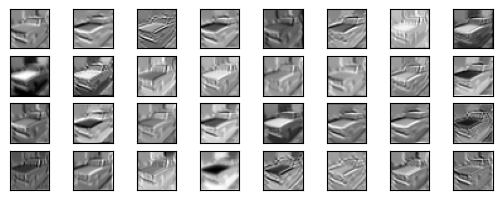

In [179]:
square = 8
ix = 1
for _ in range(square):
    for _ in range(4):
        # specify subplot and turn of axis
        ax = plt.subplot(square, square, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(activation['conv1'][0,ix-1,:,:].cpu().numpy(), cmap='gray')
        ix += 1
# show the figure
plt.show()

### Question 9: Transfer Learning / Fine tuning

Second, we'll load a pre-trained model (e.g. ResNet50, or VGG19). While these models haven't seen the exact images in this dataset, they have been trained on a large general corpus. Since these models have millions of weights, so we'll implement the following approach:
- Load the pretrained model (pick any from several [available models](https://pytorch.org/vision/stable/models.html))
- Freeze the weights for all the layers (in pytorch, you can do this using model_object.parameters())
- Replace the final fully connected layer, since you have a binary classification task. You can add additional fully connected layers if you wish, alongwith related activation functions etc.
- Finally, train this new model for 10 epochs.
- Report the performance on the train and validation sets. 
    

In [180]:
import torch
import torch.nn as nn
from torchvision import models
from datetime import datetime

# Load pretrained ResNet50
resnet = models.resnet50(weights='DEFAULT')

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final fully connected layer for binary classification (2 classes)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)  # Output logits for 2 classes (no sigmoid or softmax here)
)



# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/ramirezamayas/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


In [181]:
print(datetime.now())

training( 
    model = resnet,
    n_epochs = 10,
    optimizer = optimizer,
    
    fn_loss = loss_fn,
    data_loader = train_loader,
)

print(datetime.now())

2026-04-07 16:34:07.105063
Epoch 10. Train loss 0.25712580671386115
2026-04-07 16:39:26.662445


In [182]:
validate(resnet, train_loader)

Accuracy: 0.96
Precision: 0.95
Recall: 0.97
F1 Score: 0.96


### Question 10

Compare model performance and summarize your observations. 